<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


This exercise, will focus on data visualization. The dataset will be provided through an RDBMS, and will need to use SQL queries to extract the required data.


## Objectives


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




In [3]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0272EN-SkillsNetwork/labs/dataset/2016.csv"



In [5]:
# Path or URL to the CSV file
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0272EN-SkillsNetwork/labs/dataset/2016.csv"

# Read the CSV file into a pandas DataFrame.
# The first row is used as the column headers by default.
df = pd.read_csv(file_path)

# Print the first five rows
print(df.head())

       Country          Region  Happiness Rank  Happiness Score  \
0      Denmark  Western Europe               1            7.526   
1  Switzerland  Western Europe               2            7.509   
2      Iceland  Western Europe               3            7.501   
3       Norway  Western Europe               4            7.498   
4      Finland  Western Europe               5            7.413   

   Lower Confidence Interval Upper Confidence Interval  \
0                      7.460                     7.592   
1                      7.428                      7.59   
2                      7.333                     7.669   
3                      7.421                     7.575   
4                      7.351                     7.475   

  Economy (GDP per Capita)   Family Health (Life Expectancy)  Freedom  \
0                  1.44178  1.16374                  0.79504  0.57941   
1                  1.52733  1.14524                  0.86303  0.58557   
2                  1.42666  1

In [6]:
import pandas as pd

# File path or URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0272EN-SkillsNetwork/labs/dataset/2016.csv"

# Load the CSV file
df = pd.read_csv(file_path)

# Display the data types of each column
print("Data types of the columns:")
print(df.dtypes)

# Display additional DataFrame information
print("\nDataFrame information:")
df.info()

Data types of the columns:
Country                              str
Region                               str
Happiness Rank                     int64
Happiness Score                  float64
Lower Confidence Interval        float64
Upper Confidence Interval            str
Economy (GDP per Capita)             str
Family                           float64
Health (Life Expectancy)             str
Freedom                              str
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

DataFrame information:
<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        157 non-null    str    
 1   Region                         157 non-null    str    
 2   Happiness Rank                 157 non-null    int64  
 3   Hap

In [7]:
# ---------------------------------------------------------
# 1. Remove leading and trailing whitespace from text columns
# ---------------------------------------------------------
text_columns = df.select_dtypes(include=["object", "string"]).columns
print ("TEXT COLUMNS", text_columns)

for column in text_columns:
    df[column] = df[column].astype("string").str.strip()

# ---------------------------------------------------------
# 2. Replace empty strings with missing values
# ---------------------------------------------------------
for column in text_columns:
    df[column] = df[column].replace("", pd.NA)

# ---------------------------------------------------------
# 3. Convert columns to appropriate pandas data types
# ---------------------------------------------------------

# Convert columns that should contain numbers.
# Replace these names with the actual numeric columns in your file.
numeric_columns = [
    # "column_name_1",
    # "column_name_2",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Convert columns that should contain dates.
# Replace these names with the actual date columns in your file.
date_columns = [
    # "date_column",
]

for column in date_columns:
    df[column] = pd.to_datetime(df[column], errors="coerce")

# Use pandas' nullable data types, such as Int64, Float64, and string
df = df.convert_dtypes(dtype_backend="numpy_nullable")

# Display the resulting data types
print(df.dtypes)

# Display the first five rows
print(df.head())

TEXT COLUMNS Index(['Country', 'Region', 'Upper Confidence Interval',
       'Economy (GDP per Capita)', 'Health (Life Expectancy)', 'Freedom'],
      dtype='str')
Country                           string
Region                            string
Happiness Rank                     Int64
Happiness Score                  Float64
Lower Confidence Interval        Float64
Upper Confidence Interval         string
Economy (GDP per Capita)          string
Family                           Float64
Health (Life Expectancy)          string
Freedom                           string
Trust (Government Corruption)    Float64
Generosity                       Float64
Dystopia Residual                Float64
dtype: object
       Country          Region  Happiness Rank  Happiness Score  \
0      Denmark  Western Europe               1            7.526   
1  Switzerland  Western Europe               2            7.509   
2      Iceland  Western Europe               3            7.501   
3       Norway  Weste

In [8]:
missing_columns = df.columns[df.isna().any()].tolist()

print("Columns containing missing values:")
print(missing_columns)

# Display the number of missing values in each affected column
print("\nMissing-value count by column:")
print(df[missing_columns].isna().sum())

# 2. Replace missing values with the mean of each numeric column
numeric_missing_columns = (
    df[missing_columns]
    .select_dtypes(include="number").columns

)

df[numeric_missing_columns] = df[numeric_missing_columns].fillna(
    df[numeric_missing_columns].mean()
)

print("\nMissing values after mean replacement:")
print(df[numeric_missing_columns].isna().sum())

Columns containing missing values:
['Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Health (Life Expectancy)', 'Freedom']

Missing-value count by column:
Lower Confidence Interval    4
Upper Confidence Interval    3
Economy (GDP per Capita)     2
Health (Life Expectancy)     3
Freedom                      1
dtype: int64

Missing values after mean replacement:
Lower Confidence Interval    0
dtype: int64

       Country GDP per Capita Healthy Life Expectancy
0      Denmark        1.44178                 0.79504
1  Switzerland        1.52733                 0.86303
2      Iceland        1.42666                 0.86733
3       Norway        1.57744                 0.79579
4      Finland        1.40598                 0.81091
5       Canada        1.44015                  0.8276
6  Netherlands        1.46468                 0.81231
7  New Zealand        1.36066                 0.83096
8    Australia        1.44443                  0.8512
9       Sweden        1.45181                 0.83121

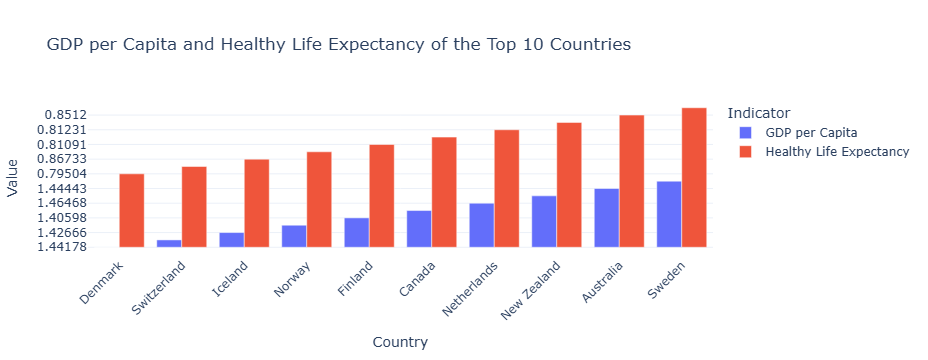

In [15]:
import pandas as pd
import plotly.express as px

# Load the 2016 World Happiness Report data
file_path = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBMSkillsNetwork-AI0272EN-SkillsNetwork/labs/dataset/2016.csv"
)

df = pd.read_csv(file_path)

# Select the top 10 countries based on Happiness Rank
top_10 = (
    df.sort_values(by="Happiness Rank", ascending=True)
      .head(10)
      [["Country", "Happiness Rank",
        "Economy (GDP per Capita)", "Health (Life Expectancy)"]]
      .copy()
)

# Rename columns for easier readability
top_10 = top_10.rename(
    columns={
        "Economy (GDP per Capita)": "GDP per Capita",
        "Health (Life Expectancy)": "Healthy Life Expectancy"
    }
)

# Display GDP per capita and healthy life expectancy for the top 10 countries
print(top_10[[
    "Country",
    "GDP per Capita",
    "Healthy Life Expectancy"
]])

# Reshape the data for a grouped bar chart
chart_data = top_10.melt(
    id_vars="Country",
    value_vars=["GDP per Capita", "Healthy Life Expectancy"],
    var_name="Measure",
    value_name="Value"
)

# Create the bar chart
fig1 = px.bar(
    chart_data,
    x="Country",
    y="Value",
    color="Measure",
    barmode="group",
    title="GDP per Capita and Healthy Life Expectancy of the Top 10 Countries",
    labels={
        "Country": "Country",
        "Value": "Value",
        "Measure": "Indicator"
    }
)

fig1.update_layout(
    xaxis_tickangle=-45,
    template="plotly_white",
    legend_title_text="Indicator"
)

# Display the chart
fig1.show()

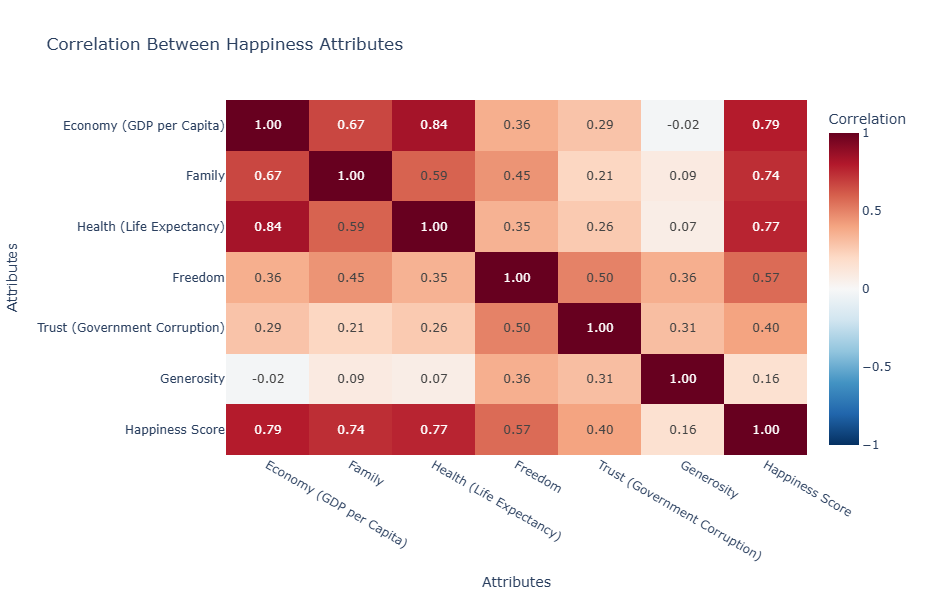

In [14]:
import plotly.express as px

# 1. Create a sub-dataset with the specified attributes
columns = [
    "Economy (GDP per Capita)",
    "Family",
    "Health (Life Expectancy)",
    "Freedom",
    "Trust (Government Corruption)",
    "Generosity",
    "Happiness Score"
]

sub_df = df[columns].copy()

# Ensure the selected columns are numeric
sub_df = sub_df.apply(pd.to_numeric, errors="coerce")

# 2. Calculate the correlation matrix
correlation_matrix = sub_df.corr()

# Create a Plotly heatmap
fig2 = px.imshow(
    correlation_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    aspect="auto",
    title="Correlation Between Happiness Attributes",
    labels={
        "x": "Attributes",
        "y": "Attributes",
        "color": "Correlation"
    },
    width=800,
    height=600
)

# Display the heatmap
fig2.show()

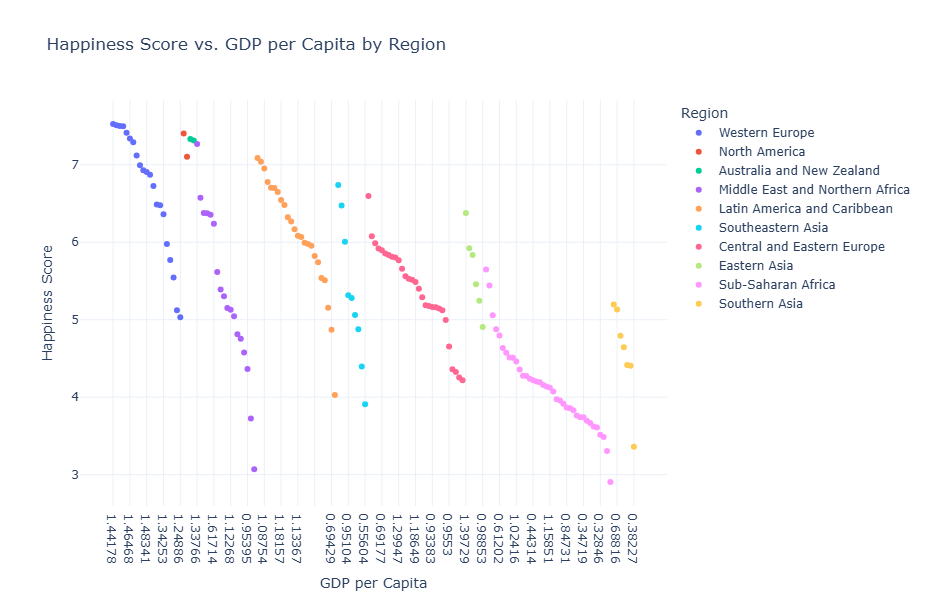

In [13]:
import plotly.express as px

# Create a scatter plot of Happiness Score vs. GDP per Capita,
# with points colored by Region
fig3 = px.scatter(
    df,
    x="Economy (GDP per Capita)",
    y="Happiness Score",
    color="Region",
    title="Happiness Score vs. GDP per Capita by Region",
    labels={
        "Economy (GDP per Capita)": "GDP per Capita",
        "Happiness Score": "Happiness Score",
        "Region": "Region"
    },
    hover_data=["Country"]
)

# Improve the chart layout
fig3.update_layout(
    template="plotly_white",
    width=800,
    height=600,
    legend_title_text="Region"
)

# Display the scatter plot
fig3.show()

                            Region  Average Happiness Score
0        Australia and New Zealand                 7.323500
1       Central and Eastern Europe                 5.370690
2                     Eastern Asia                 5.624167
3      Latin America and Caribbean                 6.101750
4  Middle East and Northern Africa                 5.386053
5                    North America                 7.254000
6                Southeastern Asia                 5.338889
7                    Southern Asia                 4.563286
8               Sub-Saharan Africa                 4.136421
9                   Western Europe                 6.685667

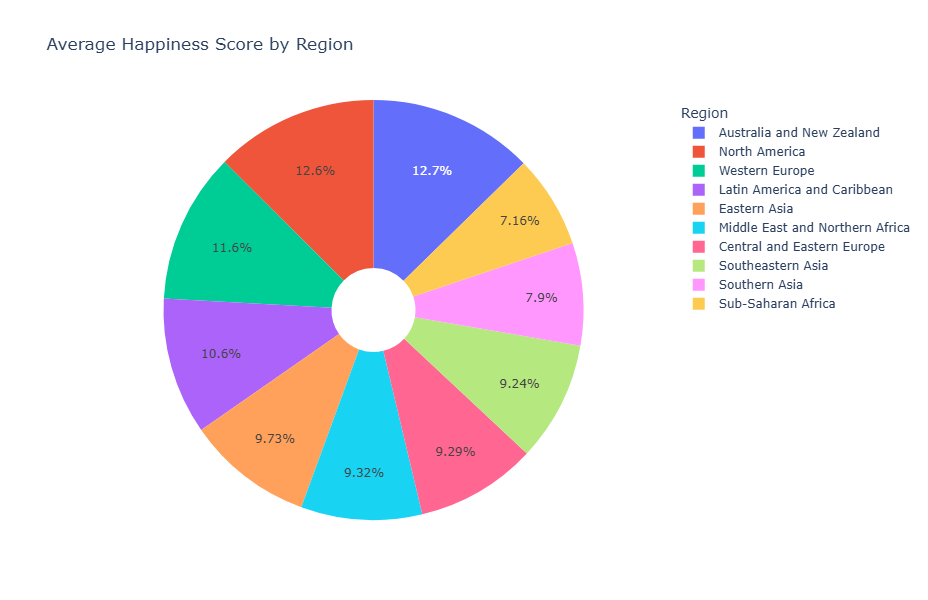

In [12]:
import plotly.express as px

# Calculate the average Happiness Score for each region
regional_happiness = (
    df.groupby("Region", as_index=False)["Happiness Score"]
      .mean()
      .rename(columns={"Happiness Score": "Average Happiness Score"})
)

print (regional_happiness)

# Create the pie chart
fig4 = px.pie(
    regional_happiness,
    values="Average Happiness Score",
    names="Region",
    title="Average Happiness Score by Region",
    hole=0.2
)

fig4.update_layout(
    width=800,
    height=600,
    legend_title_text="Region"
)

# Display the chart
fig4.show()

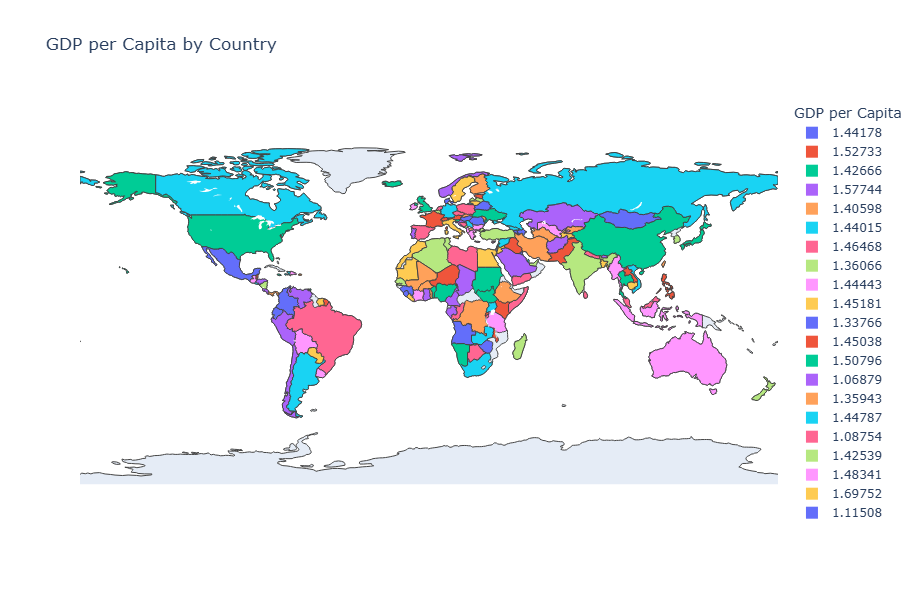

In [19]:
import plotly.express as px

# Create a world map showing GDP per capita by country
fig5 = px.choropleth(
    df,
    locations="Country",
    locationmode="country names",
    color="Economy (GDP per Capita)",
    hover_name="Country",
    hover_data={
        "Health (Life Expectancy)": ":.3f",
        "Economy (GDP per Capita)": ":.3f"
    },
    color_continuous_scale="Viridis",
    title="GDP per Capita by Country",
    labels={
        "Economy (GDP per Capita)": "GDP per Capita",
        "Health (Life Expectancy)": "Healthy Life Expectancy"
    }
)

fig5.update_layout(
    width=1000,
    height=600,
    geo=dict(showframe=False, showcoastlines=True)
)

# Display the map
fig5.show()

In [16]:
import plotly.io as pio

# Select any four figures
selected_figures = [fig1, fig2, fig3, fig4]
# For example, you could use [fig1, fig2, fig3, fig5] instead.

html_parts = [
    """
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <title>Plotly Dashboard</title>
    </head>
    <body>
        <h1>Plotly Dashboard</h1>
    """
]

# Add each figure to the HTML file
for i, fig in enumerate(selected_figures):
    html_parts.append(
        pio.to_html(
            fig,
            full_html=False,
            include_plotlyjs="cdn" if i == 0 else False
        )
    )

html_parts.append("""
    </body>
    </html>
""")

# Write all four figures to one HTML file
with open("dashboard.html", "w", encoding="utf-8") as file:
    file.write("\n".join(html_parts))

print("dashboard.html created successfully.")

dashboard.html created successfully.

In [ ]:
World Happiness Report Dashboard Narrative
Welcome to the World Happiness Report dashboard. This dashboard explores the factors associated with happiness across countries and regions, focusing particularly on the relationships between economic prosperity, health, and overall happiness.

1. Correlation Heatmap
The dashboard begins with a correlation heatmap that summarizes the relationships among the key variables in the dataset. The heatmap allows us to quickly identify which factors are positively or negatively associated with the Happiness Score.

A strong positive correlation indicates that countries with higher values for one variable generally tend to have higher happiness scores. For example, GDP per capita and Healthy Life Expectancy may show positive relationships with happiness, suggesting that economic well-being and health are important contributors to quality of life. The heatmap also helps identify variables with weak or limited relationships, as well as relationships between the explanatory variables themselves.

It is important to remember that correlation shows association, not necessarily causation.

2. GDP per Capita and Happiness Score by Region
The scatter plot examines the effect of GDP per capita on Happiness Score across different regions. Each point represents a country, while the colors distinguish the various regions.

The overall pattern helps us determine whether wealthier countries tend to report higher happiness levels. A generally upward trend would suggest that GDP per capita is positively associated with happiness. However, the spread of points also shows that economic prosperity is not the only factor influencing happiness. Countries with similar GDP per capita values may have different Happiness Scores because of differences in social support, health, freedom, generosity, or governance.

Comparing the regional clusters allows us to identify regions that tend to perform above or below the overall trend.

3. Happiness Score by Region
The pie chart presents the distribution of Happiness Scores across the different regions. It provides a high-level view of how happiness is represented geographically and highlights the relative contribution of each region to the overall happiness measure.

Regions with larger sections account for a greater share of the aggregated Happiness Score, while smaller sections represent a lower contribution. This chart is useful for quickly comparing regions, although it should be interpreted alongside the number of countries in each region and the method used to aggregate the scores. A region with more countries may naturally occupy a larger portion of the chart.

4. Global GDP per Capita Map
The final visualization is a world map displaying GDP per capita by country. The color scale makes it possible to compare economic prosperity geographically, with different shades representing different GDP per capita levels.

Hovering over a country provides additional information, including its GDP per capita and Healthy Life Expectancy. This tooltip allows users to compare economic conditions with health outcomes on a country-by-country basis.

The map highlights global differences in income and provides context for the scatter plot. It also emphasizes that GDP per capita and health are connected dimensions of national well-being, but neither measure alone fully explains happiness.

Conclusion
Together, these four charts provide a multidimensional view of global happiness. The correlation heatmap identifies important relationships, the scatter plot explores the connection between income and happiness, the pie chart compares regional contributions, and the map places economic and health indicators in a global context.

Overall, the dashboard demonstrates that GDP per capita is an important factor associated with happiness, but it is only one part of a broader picture. Healthy life expectancy and other social and institutional conditions also contribute to how people evaluate their lives.

## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-09-03 03:59:23--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv.2’

survey-data.csv.2   100%[===================>] 152.13M  7.41MB/s    in 20s     
2026-09-03 03:59:44 (7.68 MB/s) - ‘survey-data.csv.2’ saved [159525875/159525875]


**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [6]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [7]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [8]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [9]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Count the number of rows in the table named 'main'


## Demo: Running an SQL Query


In [10]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [10]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [12]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [13]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


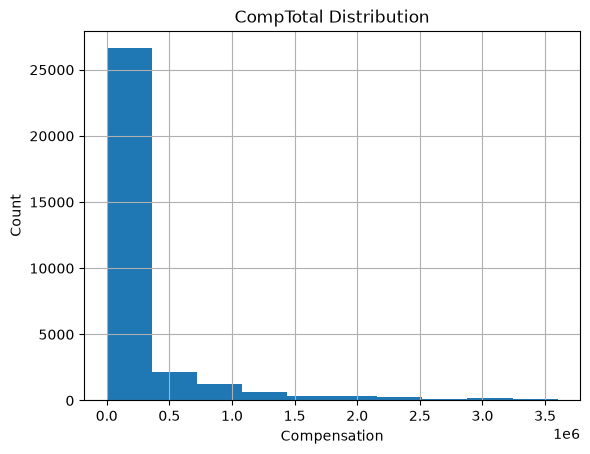

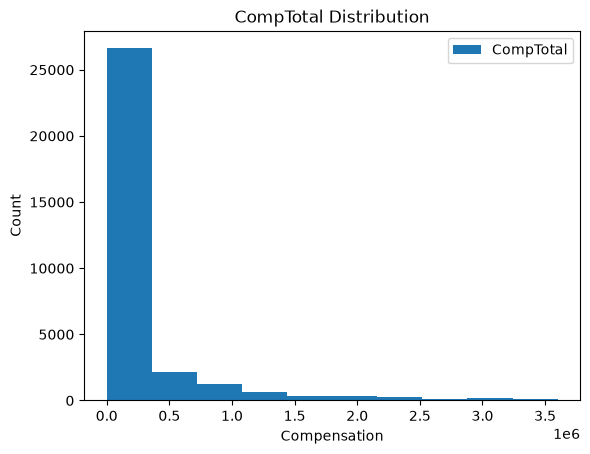

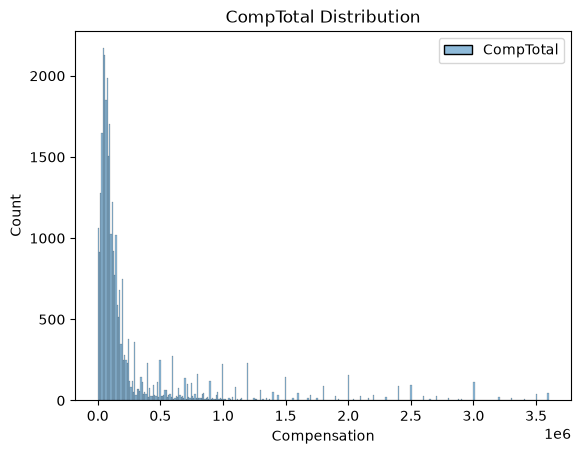

In [14]:
CompTotal = "select CompTotal from main"
CompTotal_new = pd.read_sql_query(CompTotal, conn).dropna()
upper = CompTotal_new["CompTotal"].quantile(.95)
comp_upper = CompTotal_new[CompTotal_new["CompTotal"] <= upper]

import matplotlib.pyplot as plt
import seaborn as sns
comp_upper.hist(column= "CompTotal")
plt.title("CompTotal Distribution")
plt.xlabel("Compensation")
plt.ylabel("Count")
plt.show()

comp_upper.plot(kind="hist")
plt.title("CompTotal Distribution")
plt.xlabel("Compensation")
plt.ylabel("Count")
plt.show()


sns.histplot(data=comp_upper)
plt.title("CompTotal Distribution")
plt.xlabel("Compensation")
plt.ylabel("Count")
plt.show()


**Box Plots**

Plot a box plot of Age.


                      Age
0      Under 18 years old
1         35-44 years old
2         45-54 years old
3         18-24 years old
4         18-24 years old
...                   ...
65432     18-24 years old
65433     25-34 years old
65434     25-34 years old
65435     18-24 years old
65436     18-24 years old

[65437 rows x 1 columns]
NA 0


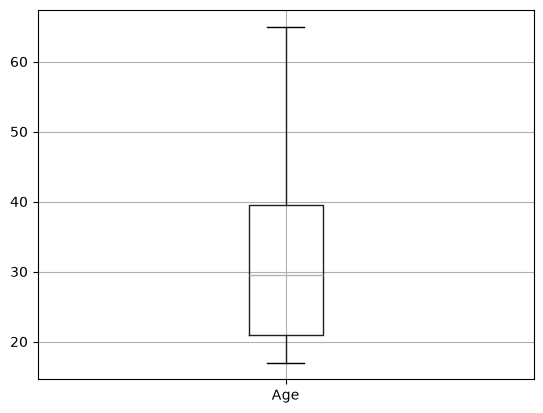

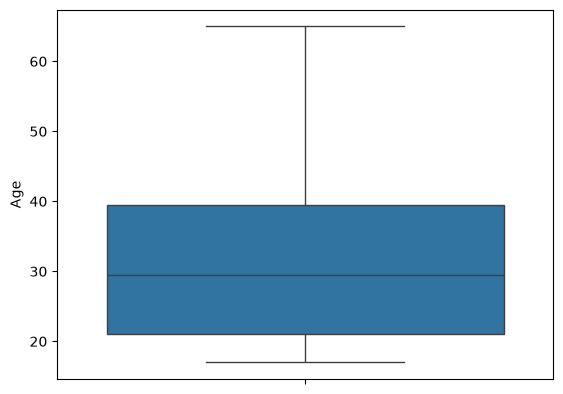

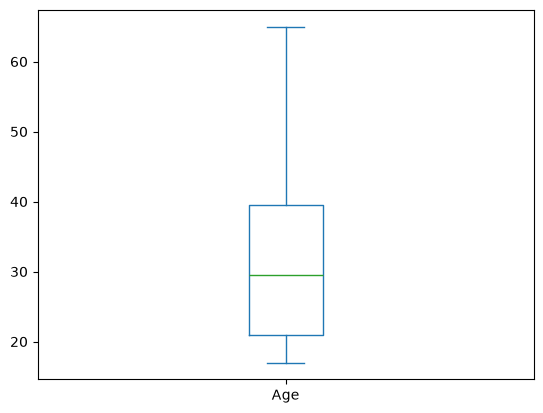

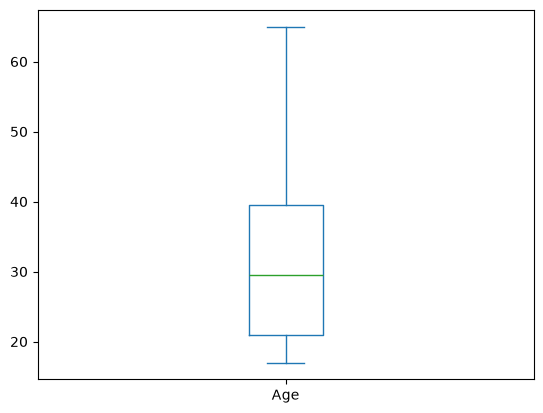

In [15]:
age = "select Age from main"
age_plot = pd.read_sql_query(age, conn).dropna()
print(age_plot)

age_map = {"Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

age_plot["Age"]= age_plot["Age"].map(age_map)
age_plot = age_plot.dropna()
print("NA", age_plot["Age"].isna().sum())

#matplotlib
age_plot.boxplot(column= "Age")
plt.show()

#seaborn
sns.boxplot(data = age_plot, y = "Age")
plt.show()

#kind
age_plot.plot(kind="box", y="Age")
plt.show()

age_plot["Age"].plot(kind="box")
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


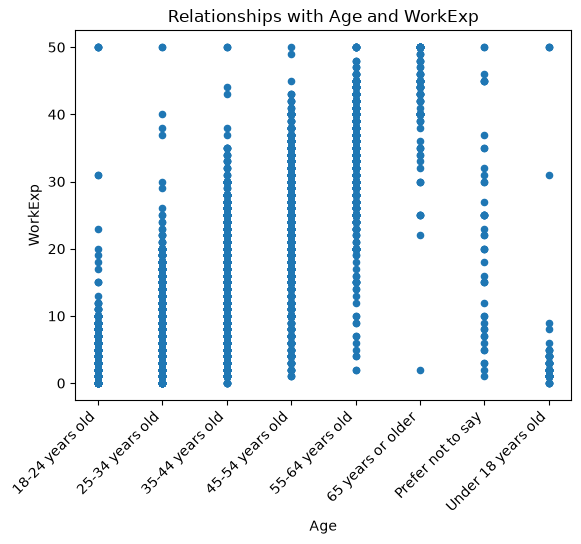

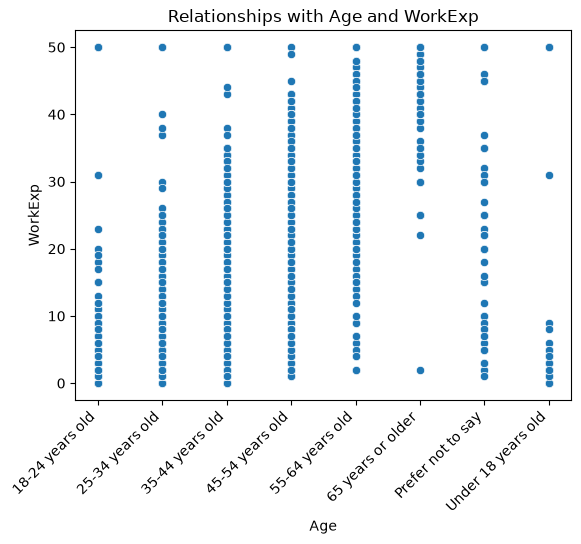

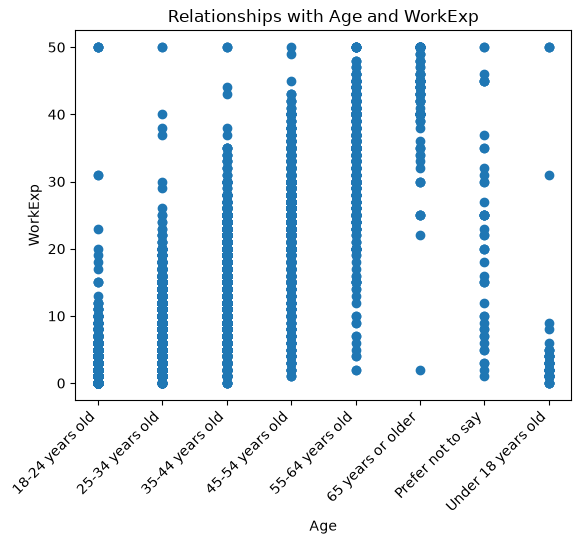

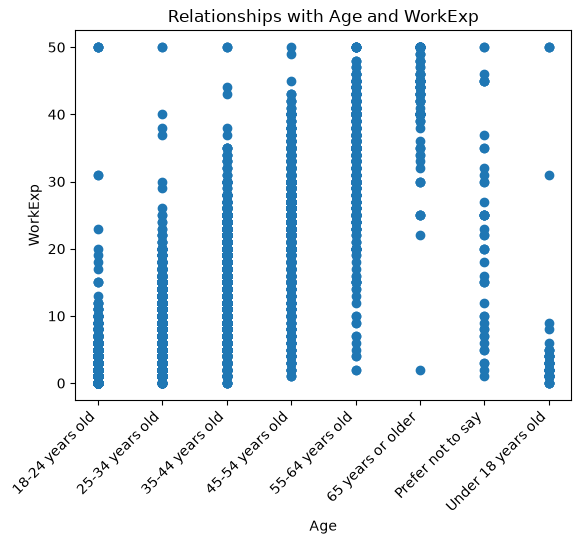

In [16]:
age_work = "select Age, WorkExp from main"
age_work_new = pd.read_sql_query(age_work, conn).dropna().sort_values("Age")

#plot kind
age_work_new.plot(kind ="scatter", x = "Age", y = "WorkExp")
plt.title("Relationships with Age and WorkExp")
plt.xlabel("Age")
plt.ylabel("WorkExp")
plt.xticks(rotation = 45, ha = "right")
plt.show()

#seaborn
sns.scatterplot(data=age_work_new, x="Age", y = "WorkExp")
plt.title("Relationships with Age and WorkExp")
plt.xlabel("Age")
plt.ylabel("WorkExp")
plt.xticks(rotation = 45, ha= "right")
plt.show()

#matplotlib

plt.scatter(data= age_work_new, x = "Age", y = "WorkExp")
plt.title("Relationships with Age and WorkExp")
plt.xlabel("Age")
plt.ylabel("WorkExp")
plt.xticks(rotation = 45, ha= "right")
plt.show()

#subplots

fig, ax = plt.subplots()
ax.scatter(data= age_work_new, x = "Age", y = "WorkExp")
ax.set_title("Relationships with Age and WorkExp")
ax.set_xlabel("Age")
ax.set_ylabel("WorkExp")
plt.xticks(rotation = 45, ha= "right")
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


                    TimeSearching  \
10            30-60 minutes a day   
12            30-60 minutes a day   
15           60-120 minutes a day   
18            15-30 minutes a day   
20     Less than 15 minutes a day   
...                           ...   
65241        60-120 minutes a day   
65265        60-120 minutes a day   
65268  Less than 15 minutes a day   
65351         15-30 minutes a day   
65412         15-30 minutes a day   

                                             Frustration              Age  
10     Amount of technical debt;Number of software to...  35-44 years old  
12     Amount of technical debt;Complexity of tech st...  35-44 years old  
15     Amount of technical debt;Complexity of tech st...  45-54 years old  
18     Amount of technical debt;Tracking my work;Comp...  25-34 years old  
20     Number of software tools in use;Tracking my wo...  25-34 years old  
...                                                  ...              ...  
65241  Amount of techni

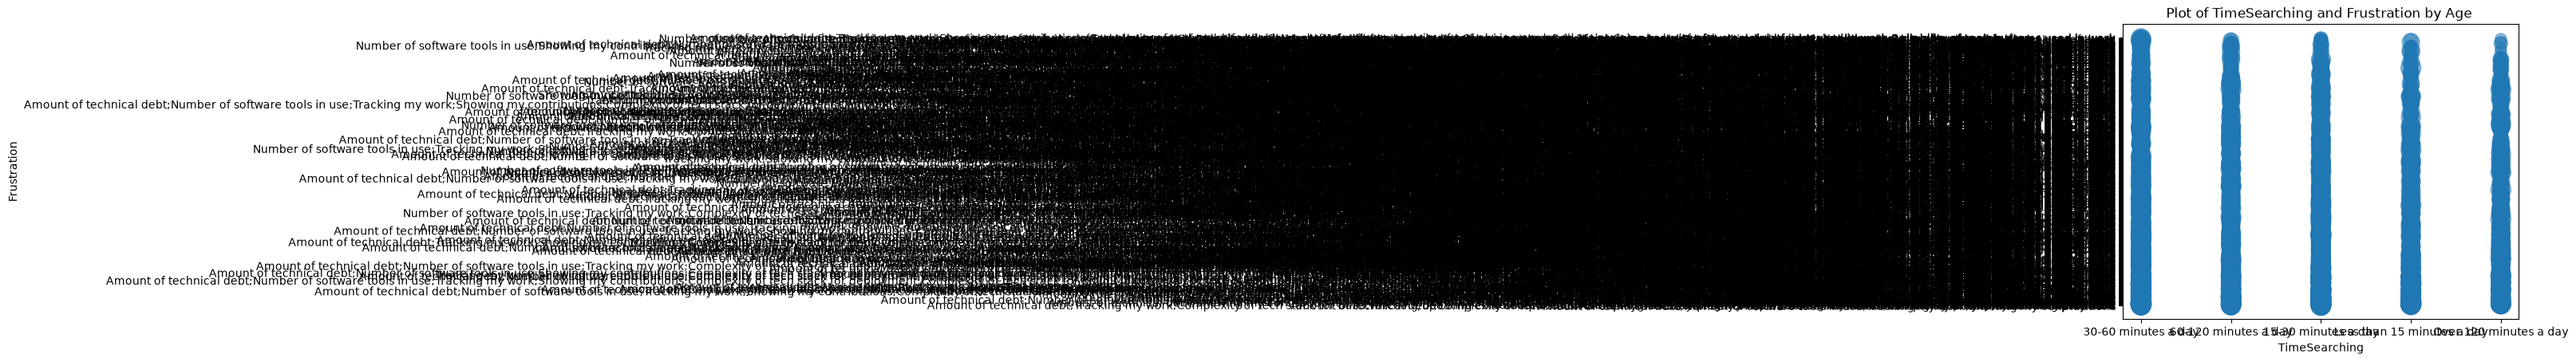

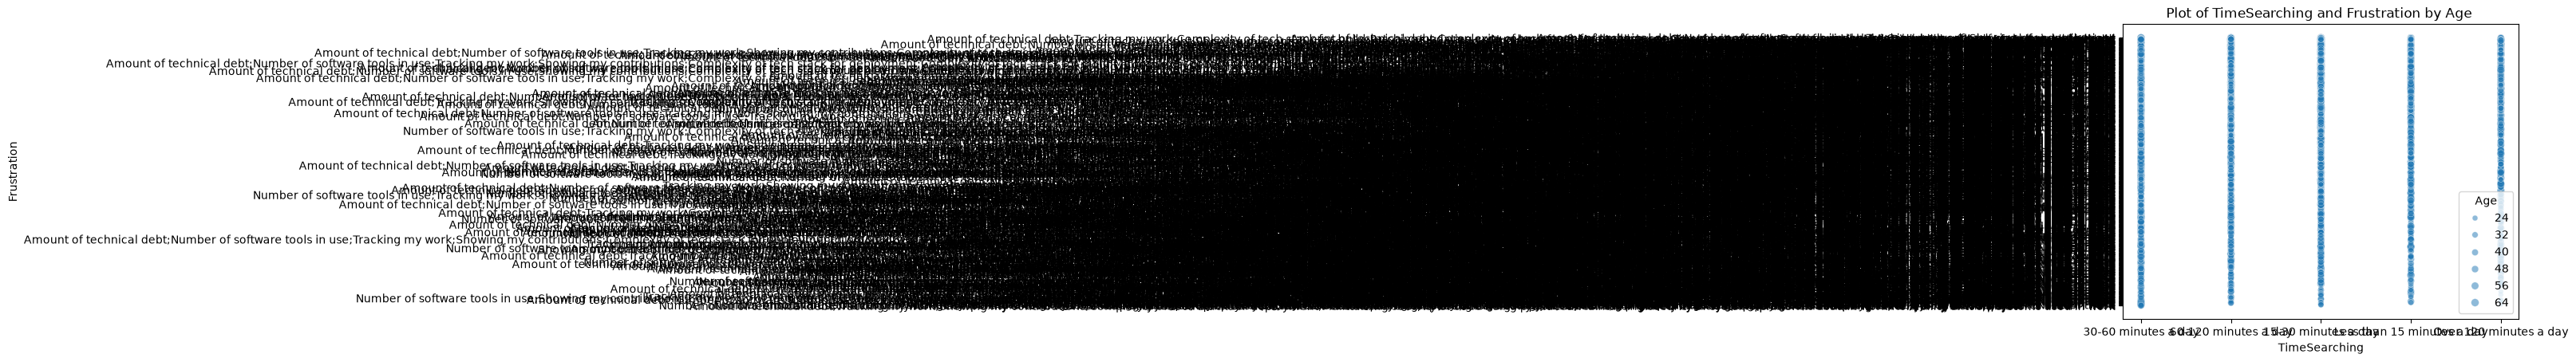

In [17]:
time_frus = "select TimeSearching, Frustration, Age from main"
time_frus_new = pd.read_sql_query(time_frus, conn).dropna()
print (time_frus_new)
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}
time_frus_new["Age"] = time_frus_new["Age"].map(age_map)
time_frus_new = time_frus_new.dropna()

"""
time_frus_new["age_group"] = pd.cut(
    time_frus_new["Age"],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=["18–24", "25–34", "35–44", "45–54", "55–64", "65-99"]
)
"""
plt.scatter(time_frus_new["TimeSearching"], time_frus_new["Frustration"], s = time_frus_new["Age"]*5, alpha= 0.5)
plt.title("Plot of TimeSearching and Frustration by Age ")
plt.xlabel("TimeSearching")
plt.ylabel("Frustration")
plt.show()

sns.scatterplot(data = time_frus_new, x= "TimeSearching", y = "Frustration", size= "Age", sizes =(20,50), alpha=0.5)
plt.title("Plot of TimeSearching and Frustration by Age ")
plt.xlabel("TimeSearching")
plt.ylabel("Frustration")
plt.show()



### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


       DatabaseWantToWorkWith  ResponseId
0                  PostgreSQL           2
1  Firebase Realtime Database           3
2    MongoDB;MySQL;PostgreSQL           4
3           PostgreSQL;SQLite           5
4             Cloud Firestore           6
SPLIT 0                    PostgreSQL
1    Firebase Realtime Database
2                       MongoDB
2                         MySQL
2                    PostgreSQL
3                    PostgreSQL
3                        SQLite
4               Cloud Firestore
Name: DatabaseWantToWorkWith, dtype: str
TOP 5 DatabaseWantToWorkWith
PostgreSQL                    3
Firebase Realtime Database    1
MongoDB                       1
MySQL                         1
SQLite                        1
Name: count, dtype: int64


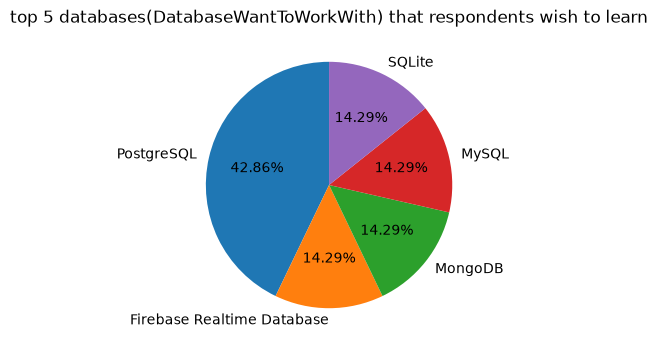

In [21]:
to_work_with = "select DatabaseWantToWorkWith, ResponseId from main  WHERE DatabaseWantToWorkWith is not null limit 5"
toworkwith_new = pd.read_sql_query(to_work_with, conn).dropna()
print (toworkwith_new)

data_split = toworkwith_new["DatabaseWantToWorkWith"].str.split(";").explode().str.strip()
print ("SPLIT", data_split)
top5 = data_split.value_counts().head()
print ("TOP 5", top5)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
plt.pie(top5.values, labels = top5.index, autopct="%.2f%%", startangle=90)
plt.title("top 5 databases(DatabaseWantToWorkWith) that respondents wish to learn")
plt.show()


       DatabaseWantToWorkWith
1                  PostgreSQL
2  Firebase Realtime Database
3    MongoDB;MySQL;PostgreSQL
4           PostgreSQL;SQLite
1                    PostgreSQL
2    Firebase Realtime Database
3                       MongoDB
3                         MySQL
3                    PostgreSQL
4                    PostgreSQL
4                        SQLite
Name: DatabaseWantToWorkWith, dtype: str
DatabaseWantToWorkWith
PostgreSQL                    3
Firebase Realtime Database    1
MongoDB                       1
MySQL                         1
SQLite                        1
Name: count, dtype: int64


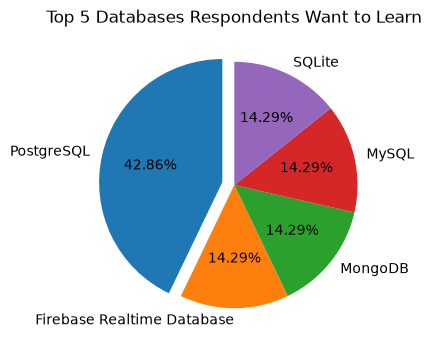

In [23]:
to_work_with = "select DatabaseWantToWorkWith from main limit 5"
toworkwith_new = pd.read_sql_query(to_work_with, conn).dropna()
print (toworkwith_new)

data_split = toworkwith_new["DatabaseWantToWorkWith"].str.split(";").explode().str.strip()
print (data_split)
top5 = data_split.value_counts().head()
print (top5)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
plt.pie(top5.values, labels = top5.index, autopct="%.2f%%", startangle=90, explode=[0.1,0,0,0,0,])
plt.title("Top 5 Databases Respondents Want to Learn")
plt.show()


**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


                    TimeSearching               TimeAnswering              Age
1             15-30 minutes a day         30-60 minutes a day  25-34 years old
2      Less than 15 minutes a day         15-30 minutes a day  25-34 years old
3            60-120 minutes a day         15-30 minutes a day  25-34 years old
6            60-120 minutes a day         15-30 minutes a day  25-34 years old
8             30-60 minutes a day         15-30 minutes a day  25-34 years old
...                           ...                         ...              ...
23805         15-30 minutes a day         15-30 minutes a day  25-34 years old
23806        60-120 minutes a day         15-30 minutes a day  25-34 years old
23836        60-120 minutes a day         30-60 minutes a day  25-34 years old
23842  Less than 15 minutes a day  Less than 15 minutes a day  25-34 years old
23874         15-30 minutes a day  Less than 15 minutes a day  25-34 years old

[12519 rows x 3 columns]
TimeSearching    45.0
Time

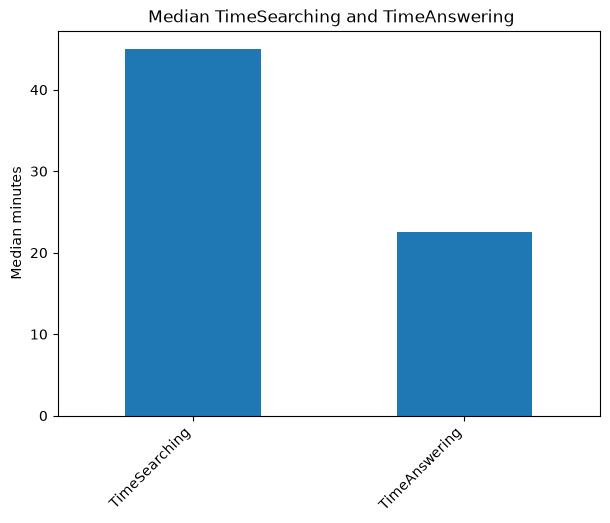

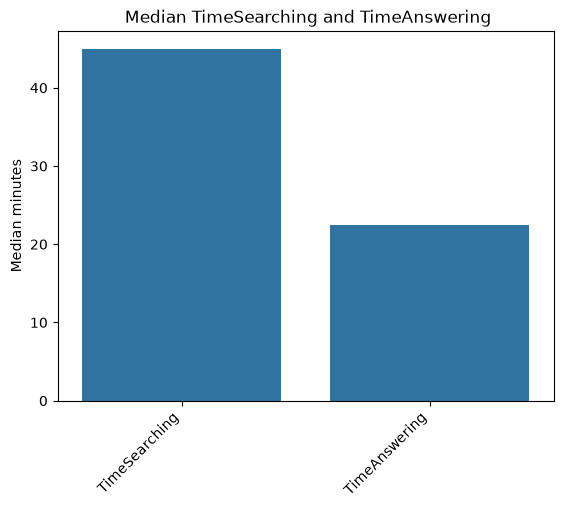

In [24]:
#query = "select DISTINCT TimeAnswering from main where TimeSearching is not null"
#print (pd.read_sql_query(query, conn))
time_search_answer = "select TimeSearching,TimeAnswering, Age from main where Age = '25-34 years old'"
time_search_answer_median = pd.read_sql_query(time_search_answer, conn).dropna()
print(time_search_answer_median)

time_map = {
    "Less than 15 minutes a day": 7.5,
    "15-30 minutes a day": 22.5,
    "30-60 minutes a day": 45,
    "60-120 minutes a day": 90,
    "Over 120 minutes a day": 120,
}
time_search_answer_median["TimeSearching"]= time_search_answer_median["TimeSearching"].map(time_map)
time_search_answer_median["TimeAnswering"] = time_search_answer_median["TimeAnswering"].map(time_map)

median_values = time_search_answer_median[["TimeSearching","TimeAnswering"]].dropna().median()
print(median_values)

median_values.plot(kind="bar", stacked= True, figsize=(7,5))
plt.title(" Median TimeSearching and TimeAnswering")
plt.ylabel("Median minutes")
plt.xticks(rotation = 45, ha="right")
plt.show()

sns.barplot(data=median_values)
plt.title(" Median TimeSearching and TimeAnswering")
plt.ylabel("Median minutes")
plt.xticks(rotation = 45, ha="right")
plt.show()


### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


      CompTotal              Age
69      95000.0  45-54 years old
71     195000.0  45-54 years old
73      54000.0  55-64 years old
76     145000.0  45-54 years old
78      80000.0  55-64 years old
...         ...              ...
8799    40000.0  45-54 years old
8807   250000.0  45-54 years old
8811   250000.0  45-54 years old
8812   157000.0  45-54 years old
8823    55000.0  45-54 years old

[4795 rows x 2 columns]
GROUP BY Age
45-54 years old    130000.0
55-64 years old    135000.0
Name: CompTotal, dtype: float64


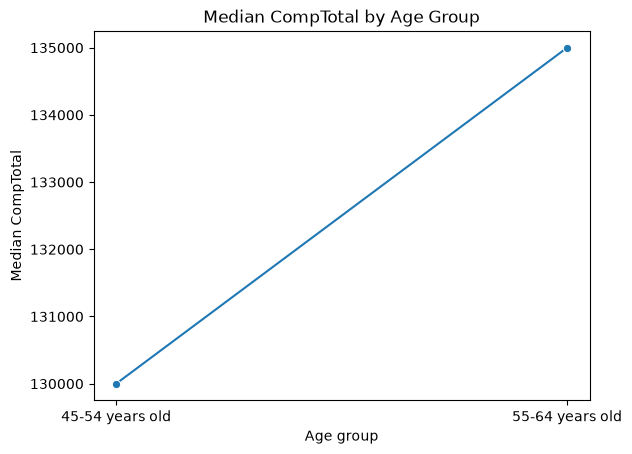

In [29]:
#query = "select DISTINCT Age from main"
#print(pd.read_sql_query(query, conn))
comptotal = "select CompTotal, Age from main where Age in ('45-54 years old', '55-64 years old')"
comptotal_median= pd.read_sql_query(comptotal, conn).dropna()
print(comptotal_median)
comp_median= comptotal_median.groupby("Age")["CompTotal"].median()
print("GROUP BY", comp_median)
#median = comptotal_median["CompTotal"].median()
#print(median)


#seaborn
sns.lineplot(x= comp_median.index, y= comp_median.values, marker = "o")
plt.xlabel("Age group")
plt.ylabel("Median CompTotal")
plt.title("Median CompTotal by Age Group")
plt.show()



In [ ]:
## Write your code here

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


                           MainBranch
0      I am a developer by profession
1      I am a developer by profession
2      I am a developer by profession
3               I am learning to code
4      I am a developer by profession
...                               ...
65432  I am a developer by profession
65433  I am a developer by profession
65434  I am a developer by profession
65435  I am a developer by profession
65436     I code primarily as a hobby

[65437 rows x 1 columns]
MainBranch
I am a developer by profession    50207
Not developer but write code       6511
I am learning to code              3875
I code primarily as a hobby        3334
Was used to be a developer         1510
Name: count, dtype: int64


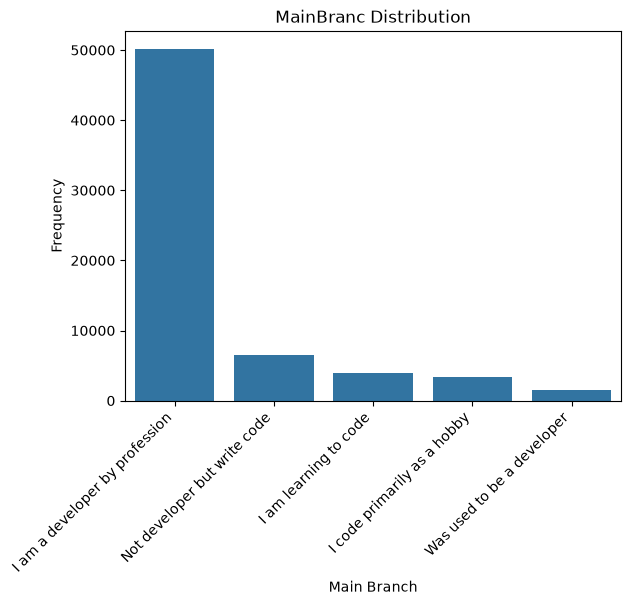

In [36]:
main_branch = "select MainBranch from main"
main_branch_new =  pd.read_sql_query(main_branch, conn).dropna()
main_branch_new["MainBranch"]= main_branch_new["MainBranch"].replace({"I am not primarily a developer, but I write code sometimes as part of my work/studies":"Not developer but write code", "I used to be a developer by profession, but no longer am":"Was used to be a developer"})
print(main_branch_new)
counts = main_branch_new["MainBranch"].value_counts()
print(counts)
#seaborn
sns.barplot(data=counts)
plt.title("MainBranc Distribution")
plt.xlabel("Main Branch")
plt.ylabel("Frequency")
plt.xticks(rotation = 45, ha ="right")
plt.show()

### Summary


In this exercise, focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. Applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

Copyright © IBM Corporation. All rights reserved.
